In [1]:
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv(find_dotenv())

True

In [3]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def call_model(state: ChatState):
    messages = []

    if state['summary']:
        messages.append(
            {
                "role": "system",
                "content": f"Conversation Summary: \n{state['summary']}"
            }
        )
    messages.extend(state['messages'])
    print(f"Messages: {messages}")
    response = llm.invoke(messages)
    return {'messages': [response]}

In [6]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages for context, remove the rest
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def should_summarize(state: ChatState):
    # Summarize if more than 6 messages in the conversation
    return len(state["messages"]) > 6

In [8]:
graph = StateGraph(state_schema=ChatState)
graph.add_node("call_model", call_model)
graph.add_node("summarize_conversation", summarize_conversation)
graph.add_edge(START, 'call_model')
graph.add_conditional_edges(
    'call_model',
    should_summarize,
    {
        True: 'summarize_conversation',
        False: END
    }   
)
graph.add_edge('summarize_conversation', END)

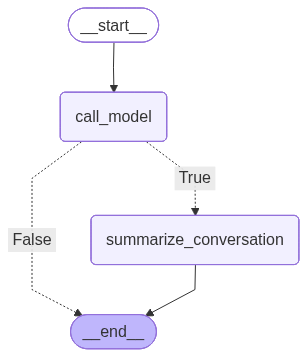

In [9]:
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# gives the current version of the state
def show_state():
    snap = workflow.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:
result = workflow.invoke({'messages': [HumanMessage(content="Quantum Physics")], 'summary': ''}, config=config)
print((result['messages'][-1].content))
show_state()

Messages: [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='09ce01e7-a008-4a94-9a24-260b1fbd05cd')]
Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. Unlike classical physics, which works well for macroscopic objects, quantum physics explains phenomena that classical theories cannot, such as the discrete nature of energy levels, wave-particle duality, and quantum entanglement.

### Key Concepts in Quantum Physics:

1. **Wave-Particle Duality**  
   Particles like electrons and photons exhibit both wave-like and particle-like properties. For example, electrons can produce interference patterns (a wave property) but also collide like particles.

2. **Quantization**  
   Certain physical quantities, such as energy, angular momentum, and charge, can only take on discrete values rather than a continuous rang

In [13]:
result = workflow.invoke({'messages': [HumanMessage(content="Who is the PM of India?")], 'summary': ''}, config=config)
print((result['messages'][-1].content))
show_state()

Messages: [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='09ce01e7-a008-4a94-9a24-260b1fbd05cd'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. Unlike classical physics, which works well for macroscopic objects, quantum physics explains phenomena that classical theories cannot, such as the discrete nature of energy levels, wave-particle duality, and quantum entanglement.\n\n### Key Concepts in Quantum Physics:\n\n1. **Wave-Particle Duality**  \n   Particles like electrons and photons exhibit both wave-like and particle-like properties. For example, electrons can produce interference patterns (a wave property) but also collide like particles.\n\n2. **Quantization**  \n   Certain physical quantities, such as energy, angular momentum, and charge, can only take on discrete values ra

In [14]:
result = workflow.invoke({'messages': [HumanMessage(content="What is the capital of France?")], 'summary': ''}, config=config)
print((result['messages'][-1].content))
show_state()

Messages: [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='09ce01e7-a008-4a94-9a24-260b1fbd05cd'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. Unlike classical physics, which works well for macroscopic objects, quantum physics explains phenomena that classical theories cannot, such as the discrete nature of energy levels, wave-particle duality, and quantum entanglement.\n\n### Key Concepts in Quantum Physics:\n\n1. **Wave-Particle Duality**  \n   Particles like electrons and photons exhibit both wave-like and particle-like properties. For example, electrons can produce interference patterns (a wave property) but also collide like particles.\n\n2. **Quantization**  \n   Certain physical quantities, such as energy, angular momentum, and charge, can only take on discrete values ra

In [15]:
result = workflow.invoke({'messages': [HumanMessage(content="What is the population of Japan?")], 'summary': ''}, config=config)
print((result['messages'][-1].content))
show_state()

Messages: [HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='09ce01e7-a008-4a94-9a24-260b1fbd05cd'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy at the smallest scales, such as atoms and subatomic particles. Unlike classical physics, which works well for macroscopic objects, quantum physics explains phenomena that classical theories cannot, such as the discrete nature of energy levels, wave-particle duality, and quantum entanglement.\n\n### Key Concepts in Quantum Physics:\n\n1. **Wave-Particle Duality**  \n   Particles like electrons and photons exhibit both wave-like and particle-like properties. For example, electrons can produce interference patterns (a wave property) but also collide like particles.\n\n2. **Quantization**  \n   Certain physical quantities, such as energy, angular momentum, and charge, can only take on discrete values ra